<img src="https://raw.githubusercontent.com/saceballes/aps_entregas/main/logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# TS1: Síntesis y operaciones de señales
#### Sebastián Ceballes


# Consignas
# Ejercicio 1:  
Utilizando siempre N = 1000 muestras. Se pide:

Sintetizar:

Señal sinusoidal de 2 KHz que tenga al menos 10 puntos por período.
Misma señal con 2 W de potencia media y desfasada en π/2.
Una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.
Una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W. 
Un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50% (Ver scipy.signal apartado Waveforms).
Para cada señal visualice el módulo de la transformada de Fourier.


Bonus:
🤯 Implementar alguna otra señal disponible en scipy.signal.
💎 Averiguar cómo se podría medir la potencia mediante la transformada de Fourier (Ver Teorema de Parseval)

# Ejercicio 2: 
Hacer en lápiz y papel y subir un PDF con la resolución.

Dado h[n] = δ[n] - δ[n - 4], encontrar y[n] = x[n] * h[n] para cada una de las siguientes x[n]:

a) x[n] = cos(ω₀.n. TS). Expresar la respuesta como un único coseno de la forma A cos(ω₀. n . TS + φ).

b) x[n] = (1/2)ⁿ u[n].

c) x[n] = u[n + 1] - u[n - 2].

Bonus:

🤯 Calcular la DFT de y(n) para N=8.
💎 Simular en Python. Ver la función convolve y FFT.
Ejercicio 2: 
Hacer en lápiz y papel y subir un PDF con la resolución.

Dado h[n] = δ[n] - δ[n - 4], encontrar y[n] = x[n] * h[n] para cada una de las siguientes x[n]:

a) x[n] = cos(ω₀.n. TS). Expresar la respuesta como un único coseno de la forma A cos(ω₀. n . TS + φ).

b) x[n] = (1/2)ⁿ u[n].

c) x[n] = u[n + 1] - u[n - 2].

Bonus:

🤯 Calcular la DFT de y(n) para N=8.
💎 Simular en Python. Ver la función convolve y FFT.


# Resolución
# Ejercicio 1: Síntesis de Señales y Transformada de Fourier

En este cuaderno vamos a generar distintas señales digitales y a visualizar su espectro de frecuencias utilizando la Transformada Rápida de Fourier (FFT).

**Consideraciones iniciales:**
* Cantidad de muestras: **N = 1000**
* Frecuencia de la señal base: **f0 = 2000 Hz** (2 KHz)
* Para cumplir con la restricción de tener al menos 10 puntos por período, la frecuencia de muestreo (**fs**) debe ser mayor o igual a $10 \cdot f_0$. Por lo tanto, definiremos **fs = 20000 Hz**.

A continuación, importamos las librerías necesarias y definimos una función auxiliar para graficar automáticamente las señales en el dominio del tiempo y de la frecuencia.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

# Parámetros principales
N = 1000
f0 = 2000  # Frecuencia de 2 KHz

# Para tener al menos 10 puntos por período, la frecuencia de muestreo (fs) 
# debe ser al menos 10 veces f0.
fs = 10 * f0  # fs = 20 KHz
Ts = 1 / fs
t = np.arange(N) * Ts

# Función auxiliar para graficar en tiempo y frecuencia
def plot_senal_y_fft(t, sig, titulo, muestras_tiempo=50):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    # Dominio del tiempo (se muestran solo algunas muestras para claridad)
    ax1.plot(t[:muestras_tiempo], sig[:muestras_tiempo], marker='.')
    ax1.set_title(f'Tiempo: {titulo}')
    ax1.set_xlabel('Tiempo [s]')
    ax1.set_ylabel('Amplitud [V]')
    ax1.grid(True)
    
    # Dominio de la frecuencia (FFT)
    xf = fftfreq(N, Ts)[:N//2]
    yf = fft(sig)
    ax2.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
    ax2.set_title('Frecuencia: Módulo de la FFT')
    ax2.set_xlabel('Frecuencia [Hz]')
    ax2.set_ylabel('Magnitud')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    

## 1. Señal sinusoidal de 2 KHz

Sintetizamos una señal senoidal estándar con amplitud unitaria. La ecuación discreta es $x[n] = \sin(2\pi f_0 n T_s)$. 
Al observar el gráfico de la FFT, deberíamos ver un único pico de frecuencia exactamente en **2 KHz**.

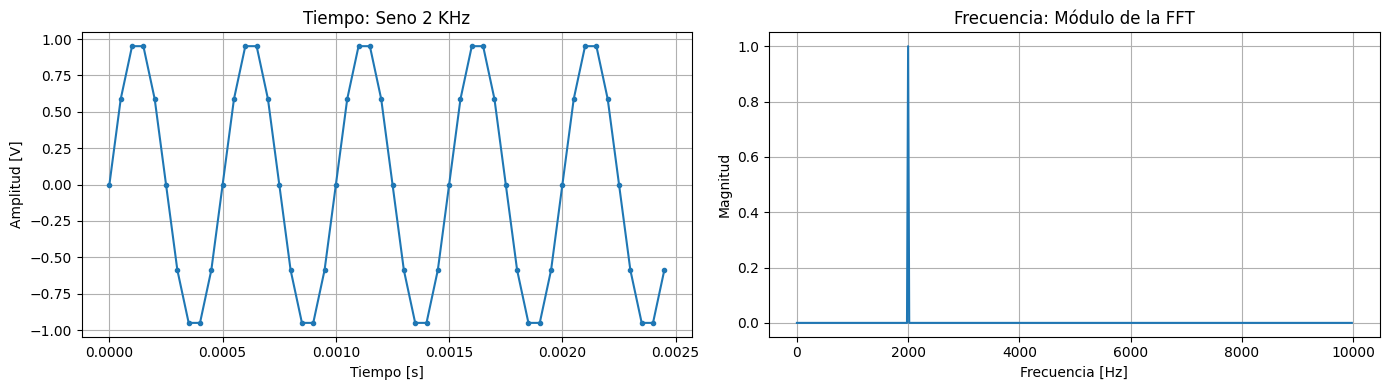

In [2]:
# 1. Señal sinusoidal estándar (Amplitud = 1V)
sig_sin = np.sin(2 * np.pi * f0 * t)
plot_senal_y_fft(t, sig_sin, 'Seno 2 KHz')


## 2. Señal sinusoidal con 2 W de potencia y desfase de π/2

Para modificar la potencia media de una señal senoidal pura, ajustamos su amplitud. La potencia de una onda senoidal de amplitud $A$ está dada por:
$P = \frac{A^2}{2}$

Si requerimos que $P = 2\text{ W}$, entonces $A = \sqrt{4} = 2$. Además, le agregamos un desfase de $\pi/2$ radianes (lo que matemáticamente la convierte en una función coseno).

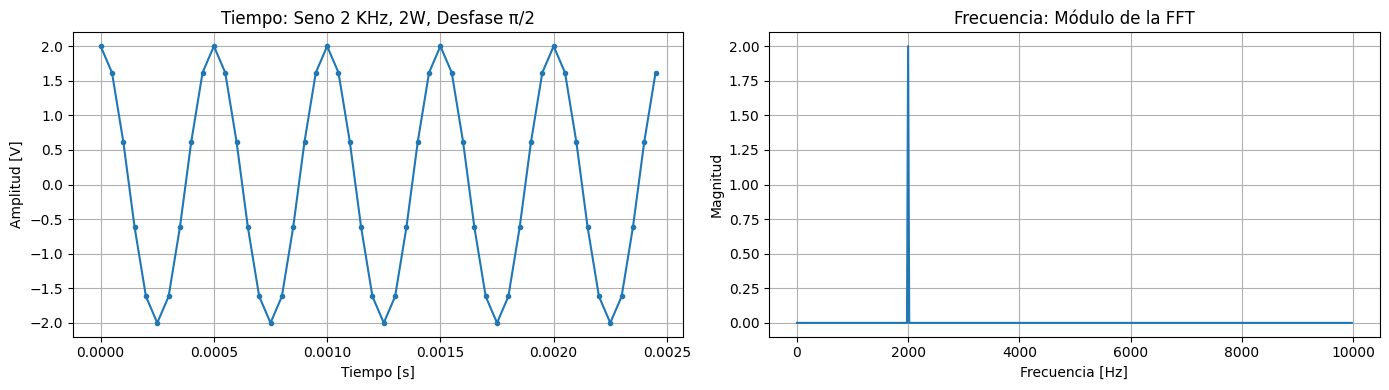

In [3]:
# 2. Potencia media de una senoidal es (A^2)/2. 
# Para P = 2W, necesitamos A = sqrt(4) = 2.
# Desfase de pi/2 en un seno equivale a un coseno.
A_2w = np.sqrt(4)
sig_sin_2w = A_2w * np.sin(2 * np.pi * f0 * t + np.pi/2)
plot_senal_y_fft(t, sig_sin_2w, 'Seno 2 KHz, 2W, Desfase π/2')

## 3 y 4. Secuencias de ruido aleatorio (Normal y Uniforme)

El ruido blanco es una señal aleatoria. En términos estadísticos:
* El nivel de **DC (valor medio 0V)** significa que la media poblacional es $\mu = 0$.
* La **potencia AC** de una señal de media cero equivale a su varianza ($\sigma^2$). 

Se pide una potencia de **0.1 W**, por lo que la varianza debe ser $0.1$.
* **Distribución Normal (Gaussiana):** Su desviación estándar será $\sigma = \sqrt{0.1}$.
* **Distribución Uniforme:** Para una variable uniforme entre $-a$ y $a$, la varianza es $\sigma^2 = \frac{a^2}{3}$. Despejando, necesitamos que la amplitud pico sea $a = \sqrt{0.3}$.

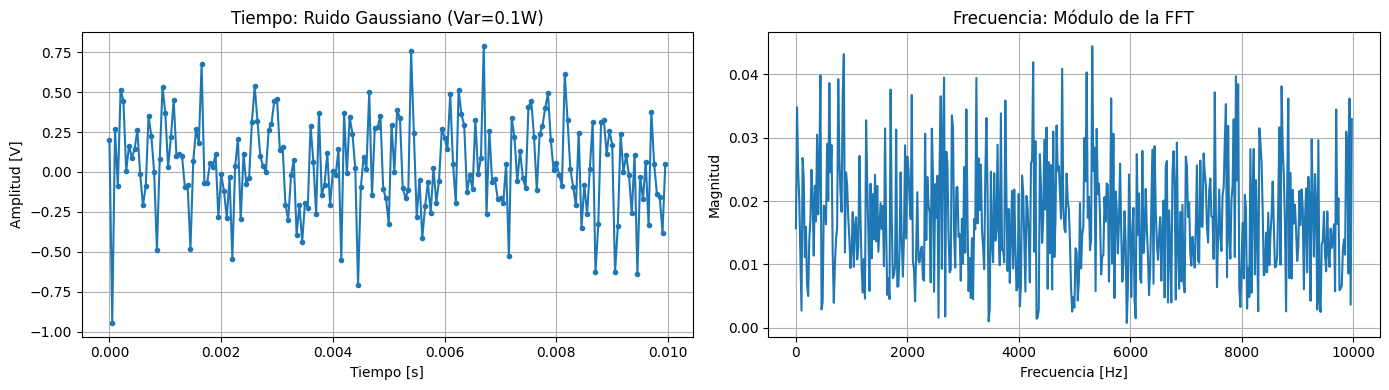

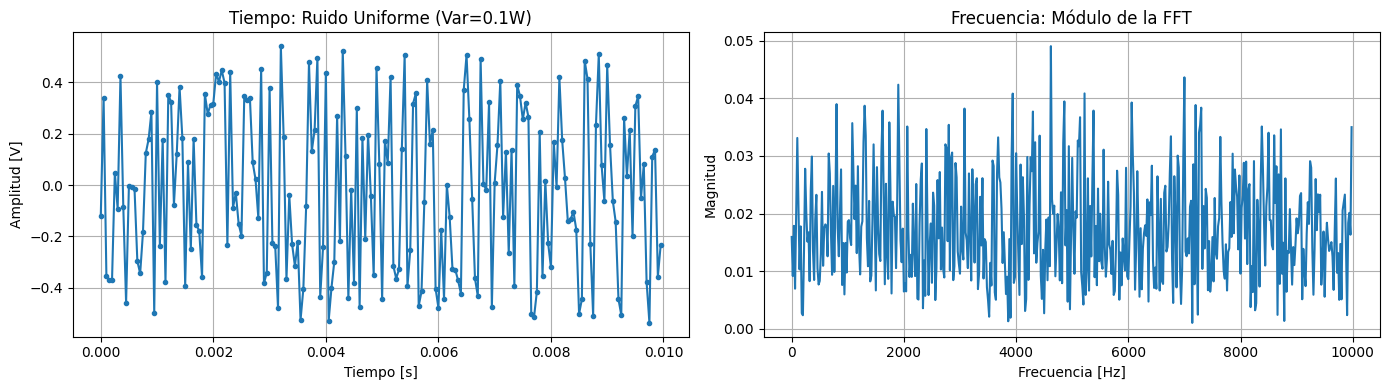

In [5]:
# 3. Ruido normal: varianza (sigma^2) = 0.1 W, media (mu) = 0
sigma_norm = np.sqrt(0.1)
sig_ruido_norm = np.random.normal(0, sigma_norm, N)
plot_senal_y_fft(t, sig_ruido_norm, 'Ruido Gaussiano (Var=0.1W)', muestras_tiempo=200)
# 4. Ruido uniforme: varianza = (2a)^2 / 12 = a^2 / 3. 
# Para Varianza = 0.1 W, a = sqrt(0.3)
a_uni = np.sqrt(0.3)
sig_ruido_uni = np.random.uniform(-a_uni, a_uni, N)
plot_senal_y_fft(t, sig_ruido_uni, 'Ruido Uniforme (Var=0.1W)', muestras_tiempo=200)

## 5. Pulso rectangular

Utilizaremos la función `square` del módulo `scipy.signal` para generar un tren de pulsos rectangulares.
* **Frecuencia:** 2 KHz.
* **Ciclo de actividad (Duty Cycle):** 50%.
* **Potencia:** 1 W. Para una onda cuadrada simétrica (que alterna entre $A$ y $-A$), la potencia es directamente $A^2$. Por lo tanto, para 1 W necesitamos una amplitud de **1 V**.

A diferencia del seno, la FFT de una onda cuadrada mostrará el pico fundamental en 2 KHz y múltiples picos armónicos impares que van decreciendo en amplitud.

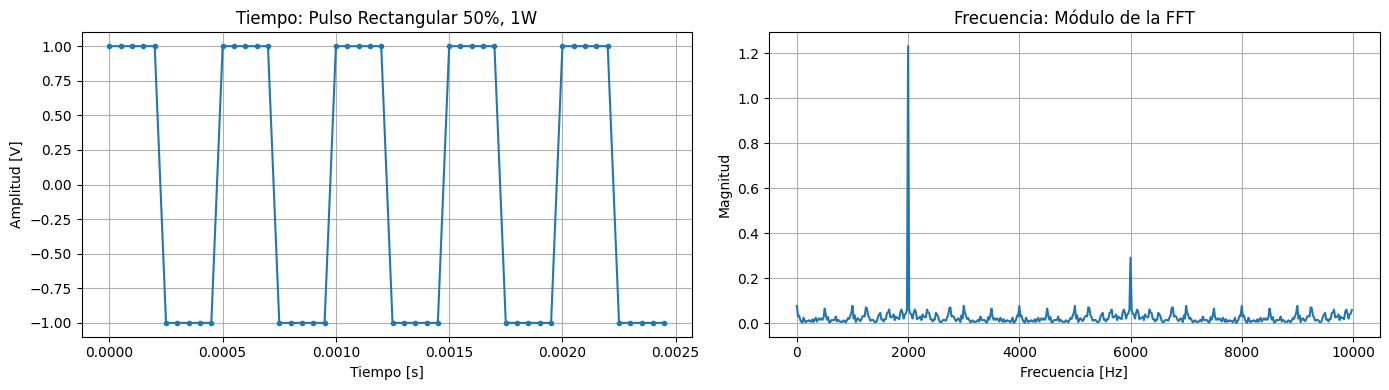

In [6]:
# 5. Pulso rectangular (square). Retorna valores entre 1 y -1.
# La potencia de esta onda cuadrada simétrica es A^2. 
# Para 1 W, A = 1.
sig_cuadrada = signal.square(2 * np.pi * f0 * t, duty=0.5)
plot_senal_y_fft(t, sig_cuadrada, 'Pulso Rectangular 50%, 1W')


## Bonus 🤯: Otra señal de scipy.signal

Para explorar el módulo de señales de SciPy, implementaremos una **señal de diente de sierra** (Sawtooth wave). Al igual que la onda cuadrada, esta señal es rica en contenido armónico, lo que se evidenciará claramente en el espectro de su transformada de Fourier (mostrando tanto armónicos pares como impares).

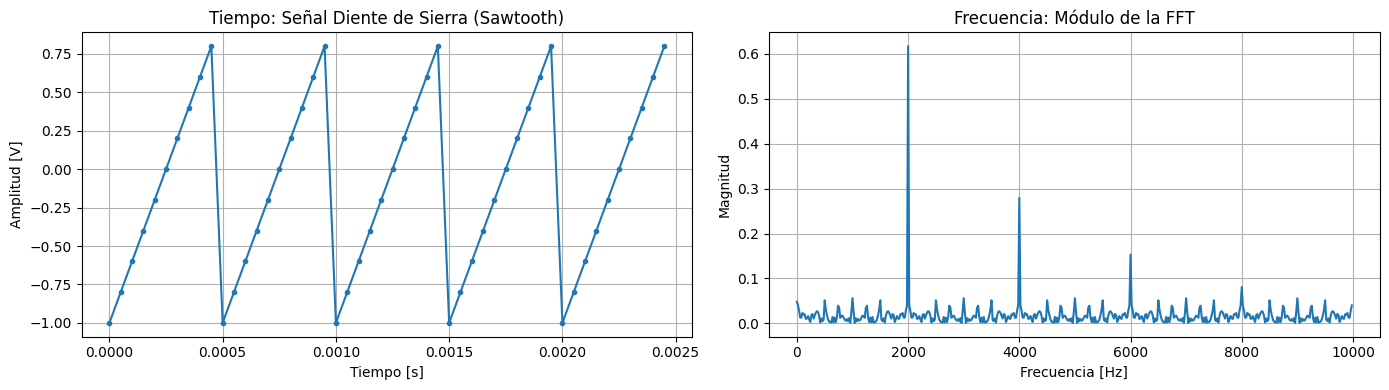

In [7]:
# Potencia de un diente de sierra simétrico de amplitud A es A^2 / 3
sig_sierra = signal.sawtooth(2 * np.pi * f0 * t)
plot_senal_y_fft(t, sig_sierra, 'Señal Diente de Sierra (Sawtooth)')

## Bonus 💎: Teorema de Parseval (Medición de potencia)

El Teorema de Parseval establece que la energía (o potencia total) de una señal es la misma independientemente de si se calcula en el dominio del tiempo o en el dominio de la frecuencia. 

Para señales discretas de longitud $N$, la equivalencia de la potencia media se expresa como:
$P = \frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N^2} \sum_{k=0}^{N-1} |X[k]|^2$

A continuación, creamos una función que calcula la potencia en ambos dominios para verificar que los resultados numéricos sean idénticos (salvo por minúsculos errores de redondeo de punto flotante).

In [8]:
def verificar_parseval(sig, nombre):
    # Potencia en el dominio del tiempo: Promedio de las muestras al cuadrado
    P_tiempo = np.mean(np.abs(sig)**2)
    
    # Potencia en el dominio de la frecuencia: Suma de los módulos de la FFT al cuadrado, dividido por N^2
    Y = fft(sig)
    P_frecuencia = np.sum(np.abs(Y)**2) / (N**2)
    
    print(f"--- {nombre} ---")
    print(f"Potencia (Tiempo):      {P_tiempo:.4f} W")
    print(f"Potencia (Frecuencia):  {P_frecuencia:.4f} W\n")

verificar_parseval(sig_sin_2w, "Seno 2W")
verificar_parseval(sig_cuadrada, "Pulso Rectangular 1W")
verificar_parseval(sig_ruido_norm, "Ruido Gaussiano 0.1W")

--- Seno 2W ---
Potencia (Tiempo):      2.0000 W
Potencia (Frecuencia):  2.0000 W

--- Pulso Rectangular 1W ---
Potencia (Tiempo):      1.0000 W
Potencia (Frecuencia):  1.0000 W

--- Ruido Gaussiano 0.1W ---
Potencia (Tiempo):      0.0945 W
Potencia (Frecuencia):  0.0945 W



# Ejercicio 2: Convolución Discreta

En este ejercicio analizamos un sistema Lineal e Invariante en el Tiempo (LTI) definido por la siguiente respuesta al impulso:
$$h[n] = \delta[n] - \delta[n - 4]$$

El objetivo es calcular analíticamente la salida del sistema $y[n] = x[n] * h[n]$ para tres señales de entrada distintas:
* **a)** $x[n] = \cos(\omega_0 n T_S)$ 
* **b)** $x[n] = \left(\frac{1}{2}\right)^n u[n]$
* **c)** $x[n] = u[n + 1] - u[n - 2]$

## Resolución Analítica (Lápiz y Papel)

El desarrollo matemático paso a paso para los incisos **a**, **b** y **c**, junto con el cálculo manual de la DFT para $N=8$, se encuentra documentado en el siguiente archivo.


In [11]:
from IPython.display import IFrame
IFrame("resolucion_ejercicio2.pdf", width=800, height=600)

## Bonus 💎: Simulación Computacional con NumPy

A continuación, verificamos de forma numérica los resultados obtenidos en el papel utilizando exclusivamente la librería `numpy`.

En el siguiente bloque de código implementamos la simulación para el inciso **c)** realizando los siguientes pasos:
1. **Definición de señales:** Armamos los vectores $x[n]$ y $h[n]$ con sus muestras exactas.
2. **Convolución Lineal:** Utilizamos `np.convolve` para deslizar y multiplicar las señales obteniendo $y[n]$.
3. **Envoltorio Circular (Circular Wrapping):** Como la señal comienza en $n=-1$, reacomodamos manualmente esa muestra en la última posición (índice 7) para preparar un arreglo de exactamente 8 puntos.
4. **Cálculo de la DFT:** Aplicamos el algoritmo `np.fft.fft` para obtener los coeficientes complejos y separamos su magnitud y fase.

In [10]:
import numpy as np

# =====================================================================
# PASO 1: DEFINIR NUESTRAS SEÑALES
# =====================================================================

# x[n] = u[n+1] - u[n-2]. Es un pulso que vale 1 en n = -1, 0, 1.
x = np.array([1, 1, 1])

# h[n] = delta[n] - delta[n-4]. 
# Vale 1 en n=0, 0 en n=1,2,3, y -1 en n=4.
# Escribimos explícitamente todas las muestras intermedias:
h = np.array([1, 0, 0, 0, -1])


# =====================================================================
# PASO 2: CONVOLUCIÓN CON 'np.convolve'
# =====================================================================

# 'np.convolve' toma los dos arreglos, los desliza uno sobre el otro,
# multiplica las muestras que se cruzan y las suma. 
y = np.convolve(x, h)

print("1. RESULTADO DE LA CONVOLUCIÓN LINEAL (y[n]):")
print("y[n] =", y)
print("Soporte temporal real del resultado: n = -1, 0, 1, 2, 3, 4, 5\n")


# =====================================================================
# PASO 3: PREPARAR LA SEÑAL PARA LA FFT DE 8 PUNTOS (N=8)
# =====================================================================

# Para calcular una FFT de N=8, necesitamos un arreglo de exactamente 8 muestras (de n=0 a n=7).
# Como nuestra convolución 'y[n]' empieza en n = -1, aplicamos la regla de "envoltorio circular" (Circular Wrapping):
# La muestra en n = -1 "da la vuelta" y se acomoda en la última posición (índice 7).
#
# El arreglo resultante de 8 puntos queda estructurado así:
# Índice en Python:    0     1     2     3     4     5     6     7 (este era el n=-1)
# Valor real:         y[0]  y[1]  y[2]  y[3]  y[4]  y[5]  y[6]  y[-1]
y_8 = np.array([       1,    1,    0,   -1,   -1,   -1,    0,    1])


# =====================================================================
# PASO 4: CALCULAR LA FFT CON 'np.fft.fft'
# =====================================================================

# 'np.fft.fft' es un algoritmo optimizado que calcula la DFT de 8 puntos.
# Nos devolverá una lista de 8 números complejos (uno para cada frecuencia 'k' de 0 a 7).
Y_fft = np.fft.fft(y_8)

print("2. RESULTADO DE LA FFT (DFT de 8 puntos):")
for k in range(8):
    # Extraemos el número complejo para la frecuencia k actual
    coeficiente = Y_fft[k]
    
    # Calculamos su Magnitud (módulo del número complejo)
    magnitud = np.abs(coeficiente)
    
    # Calculamos su Fase en radianes (ángulo del número complejo)
    fase = np.angle(coeficiente)
    
        
    print(f"Frecuencia k = {k} | Coeficiente: {coeficiente.real:.4f} + ({coeficiente.imag:.4f})j | Magnitud: {magnitud:.4f} | Fase: {fase:.4f} rad")

1. RESULTADO DE LA CONVOLUCIÓN LINEAL (y[n]):
y[n] = [ 1  1  1  0 -1 -1 -1]
Soporte temporal real del resultado: n = -1, 0, 1, 2, 3, 4, 5

2. RESULTADO DE LA FFT (DFT de 8 puntos):
Frecuencia k = 0 | Coeficiente: 0.0000 + (0.0000)j | Magnitud: 0.0000 | Fase: 0.0000 rad
Frecuencia k = 1 | Coeficiente: 4.8284 + (0.0000)j | Magnitud: 4.8284 | Fase: 0.0000 rad
Frecuencia k = 2 | Coeficiente: 0.0000 + (0.0000)j | Magnitud: 0.0000 | Fase: 0.0000 rad
Frecuencia k = 3 | Coeficiente: -0.8284 + (0.0000)j | Magnitud: 0.8284 | Fase: 3.1416 rad
Frecuencia k = 4 | Coeficiente: 0.0000 + (0.0000)j | Magnitud: 0.0000 | Fase: 0.0000 rad
Frecuencia k = 5 | Coeficiente: -0.8284 + (0.0000)j | Magnitud: 0.8284 | Fase: 3.1416 rad
Frecuencia k = 6 | Coeficiente: 0.0000 + (0.0000)j | Magnitud: 0.0000 | Fase: 0.0000 rad
Frecuencia k = 7 | Coeficiente: 4.8284 + (0.0000)j | Magnitud: 4.8284 | Fase: 0.0000 rad


## Conclusión General

A través de la resolución de estos ejercicios, logramos vincular el marco teórico del procesamiento digital de señales con la simulación computacional:

* **Análisis Espectral y Energía (Ejercicio 1):** Comprobamos cómo las características temporales de distintas señales (frecuencia, ciclo de actividad, distribución estadística del ruido) definen su firma exacta en el espectro de frecuencias. La validación numérica del **Teorema de Parseval** demostró empíricamente la conservación de la potencia al transicionar entre los dominios del tiempo y la frecuencia.
* **Sistemas LTI y DFT (Ejercicio 2):** Contrastar la convolución analítica en papel con la ejecución computacional evidenció la importancia de realizar un seguimiento riguroso del soporte temporal (el índice $n$). Además, la aplicación manual del **envoltorio circular (circular wrapping)** ilustró el paso crítico necesario para adaptar una convolución lineal a las propiedades de periodicidad que exige el cálculo de una DFT de $N$ puntos.